## A/B Test: Ecommerce Checkout Optimization

### Summary

In this project I ran an **A/B test** to evaluate a **redesigned e‑commerce checkout flow** using a dataset of 
**10,000 simulated shoppers**. 

It coveres applying a **Two‑Sample Z‑test**, **MDE power analysis**, and **Chi‑Square SRM validation** to confirm both 
statistical significance and experiment integrity. 

The project uses the following AI agents and libraries:
- Coding Environment: Google Colab (extension for Visual Studio Code)
- AI Copilot: ChatGPT (debug and interpret results) 
- Python Libraries: Pandas (data handling), statsmodels (statistical math), and scipy.stats (probability distributions)

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chisquare

### 1. Generate the Ecommerce Dataset

We will programmatically generate a **realistic e-commerce dataset** representing a **UX checkout page experiment**. The 
dataset contains **10,000 simulated shoppers**, split evenly between control and treatment groups:

- **Group A** is the **"Control" (old checkout page)** 
- **Group B** is the **"Treatment" (new, streamlined checkout page)**

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 10,000 simulated shoppers
n_shoppers = 10000

data = pd.DataFrame({
    'user_id': np.arange(1, n_shoppers + 1),
    'group': np.random.choice(['control', 'treatment'], size=n_shoppers, p=[0.5, 0.5]),
})

# Simulate a 12% conversion rate for Control, and a 14% conversion rate for Treatment
data['converted'] = data['group'].apply(
    lambda x: np.random.binomial(1, 0.12) if x == 'control' else np.random.binomial(1, 0.14)
)

#print(data.head(5))
#print("\nGroup Counts:\n", data['group'].value_counts())

data.head()

,user_id,group,converted
0,1,control,0
1,2,treatment,0
2,3,treatment,0
3,4,treatment,0
4,5,control,0


In [3]:
# Display the number of users on each group
print("Group Counts:\n", data['group'].value_counts())

Group Counts:
 control      5076
treatment    4924
Name: group, dtype: int64


### 2. Compute Conversion Rates

Next, we calculate the baseline metrics to see which group performed better on the surface level.

In [4]:
# Calculate conversion totals and rates
summary = data.groupby('group')['converted'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total Users', 'sum': 'Conversions', 'mean': 'Conversion Rate'}
)
print(summary)

           Total Users  Conversions  Conversion Rate
group                                               
control           5076          627         0.123522
treatment         4924          717         0.145613


There are **5076 users in the control group** and **4924 in the treatment group**. The number of **users** who actually **made a 
purchase** is **627 from the control group** and **717 from the treatment group**.

The conversion rate for each group (number of actual purchases divided by the number of total visitors to the page) is:
- **12.35% for the control group**
- **14.56% for the treatment group**.

### 3. Run the A/B Statistical Test

Because e-commerce conversions are binary choices - either a user purchased (1) or did not purchase (0) - we use a 
**Two-Sample Z-Test for Proportions** to determine whether the **difference in conversion rates** is **statistically 
significant**, or just random noise.

In [5]:
# Separate the groups
control_results = data[data['group'] == 'control']['converted']        
treatment_results = data[data['group'] == 'treatment']['converted']    

# Format inputs for the z-test
# nr of conversions for each group
counts = [treatment_results.sum(), 
          control_results.sum()]
# total nr of users per each group
nobs = [treatment_results.count(),
        control_results.count()]      

# Execute Z-Test
z_stat, p_value = proportions_ztest(counts, 
                                    nobs=nobs, 
                                    alternative='two-sided')

# Calculate 95% Confidence Intervals
(treatment_lower, control_lower), (treatment_upper, control_upper) = proportion_confint(counts, nobs=nobs, alpha=0.05)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Control 95% CI: [{control_lower:.4f}, {control_upper:.4f}]")
print(f"Treatment 95% CI: [{treatment_lower:.4f}, {treatment_upper:.4f}]")

Z-statistic: 3.2380
P-value: 0.0012
Control 95% CI: [0.1145, 0.1326]
Treatment 95% CI: [0.1358, 0.1555]


The **95% confidence intervals** calculated for both variants, quantify the uncertainty around the conversion estimates.

The p‑value of **0.0012** is well below 0.05. This means there is **less than a 0.12% probability** that the observed lift 
happened randomly. 

The **statistical test** confirms that **this improvement happened by chance is extremely low** — 0.12% — which means the new 
checkout design is very likely responsible for the better performance.

### 4. Visualizing the Conversion Rates

The visualization below shows the **calculated conversion rates** for **Control vs Treatment groups**.

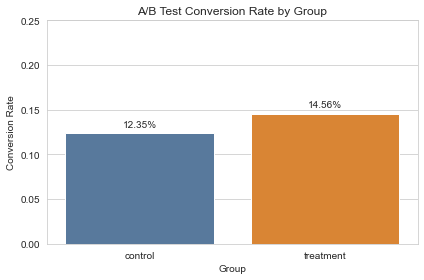

In [6]:
# Compute conversion rates by group
summary = (
    data.groupby("group")["converted"]
    .mean()
    .reset_index(name="conversion_rate")
)

# Plot the barplot
# Set style and figure size
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, 
            x="group", 
            y="conversion_rate", 
            palette=["#4C78A8", "#F58518"])

# Plot title
plt.title("A/B Test Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.ylim(0, 0.25)

# Display text
for bar in plt.gca().patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

The **control group** has a lower conversion rate of **12.35%** and the **treatment group** has a slighly higher conversion rate
of **14.45%**.

The **difference** between the conversion rates illustrates the **2% lift** created by the **treatment group over the 
control group**.

### KDEs for Calculated Conversion Distributions

Below we compute **bootstrap sampling distributions of conversion rate** for **Control vs Treatment groups**
(using 5000 bootstrap samples), and **plot their KDEs**.

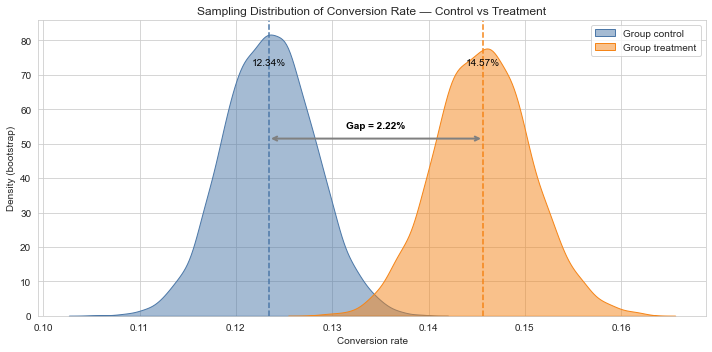

In [7]:
# Define function to bootstrap sampling distributions 
# We use 5000 bootstrap samples
def bootstrap_means(arr, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(arr)
    samples = rng.choice(arr, size=(n_boot, n), replace=True)
    return samples.mean(axis=1)

# Compute bootstrap sampling distributions of conversion rate per group

# Create list with the two groups (control and treatment)
groups = sorted(data['group'].unique())  

# Create dictionary with bootstraped conversion rate 
# sampling distributions for control and treatment groups
boots = {}
for g in groups: 
    arr = data.loc[data['group'] == g, 'converted'].values  
    boots[g] = bootstrap_means(arr, n_boot=5000, seed=42)   
    
    
# Summary stats

# Create dictionary with means and stds
# for bootstrap samples for both groups
means = {g: boots[g].mean() for g in groups}
stds = {g: boots[g].std() for g in groups}
# Calculate the gap between the two means
gap = means[groups[1]] - means[groups[0]]

# Plot KDEs and mark gap between peaks
sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
ax = plt.gca()
colors = ['#4C78A8', '#F58518']
for i, g in enumerate(groups):
    sns.kdeplot(boots[g], fill=True, bw_method='scott', label=f"Group {g}", color=colors[i], alpha=0.5)
    # Draw vertical line at mean
    plt.axvline(means[g], color=colors[i], linestyle='--')
    plt.text(means[g], plt.ylim()[1]*0.85, f"{means[g]:.2%}", color='black', ha='center') # color=colors[i]

# Annotate gap with double-headed arrow
ymax = plt.ylim()[1]
ypos = ymax * 0.6
# Marks each group's mean
plt.annotate('', xy=(means[groups[0]], ypos), xytext=(means[groups[1]], ypos), arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
mid = (means[groups[0]] + means[groups[1]]) / 2
# Annotate the gap between peaks
plt.text(mid, ypos * 1.05, f'Gap = {gap:.2%}', ha='center', va='bottom', color='black', fontsize=10, weight='semibold')

plt.title('Sampling Distribution of Conversion Rate — Control vs Treatment')
plt.xlabel('Conversion rate')
plt.ylabel('Density (bootstrap)')
plt.legend()
plt.tight_layout()
plt.show()

The **means** of the **bootstrap sampling distributions of conversion rate** are:
- **Control** group: **12.34%**
- **Treatment** group: **14.57%** 
    
The **gap between the peaks** of the KDEs for the two groups is **2.22%**.

### 5. Minimum Detectable Effect (MDE) Power Analysis

When we run an A/B test, we want to be confident that any improvement we see is real—not just random noise. Power analysis is 
the tool that tells us whether our test was big enough to reliably detect meaningful changes in customer behavior.

We'll use the **Minimum Detectable Effect (MDE) power analysis** to determine **if the sample size of 10,000 users** was large 
enough to reliably detect a **2% lift** (e.g., 12% → 14%) between treatment and control.

In [8]:
# Baseline conversion rate (control)
p1 = data.loc[data['group'] == 'control', 'converted'].mean()

# Minimum Detectable Effect (absolute difference)
mde = 0.02  # 2 percentage points
p2 = p1 + mde

# Compute effect size for two-sample proportions z-test
# Cohen's h = 2 * arcsin(sqrt(p2)) - 2 * arcsin(sqrt(p1))
effect_size = 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))

# Total sample size (control + treatment)
n_total = len(data)

analysis = NormalIndPower()

# Compute achieved power with current sample size
power = analysis.power(
    effect_size=effect_size,
    nobs1=n_total / 2,
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided',
)

print(f"Baseline conversion rate (A): {p1:.4f}")
print(f"Target conversion rate (A + MDE): {p2:.4f}")
print(f"Effect size (Cohen's h): {effect_size:.4f}")
print(f"Achieved power with n={n_total}: {power:.4f}")

# Compute required sample size to detect a 2% lift with 80% power
required_n = analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided',
)
print(f"Required sample size for 80% power: {required_n:.0f} users")

Baseline conversion rate (A): 0.1235
Target conversion rate (A + MDE): 0.1435
Effect size (Cohen's h): 0.0588
Achieved power with n=10000: 0.8369
Required sample size for 80% power: 4534 users


### Interpretation of MDE Power Analysis

The results show an **effect size (Cohen’s h)** around **0.06**, which is small. With a **2%** lift this means:
   
- Achieved a **83% power** with **n=10,000** 
- Required **sample size for 80% power** is around **5,000 users**

The **sample size of 10,000 users *was* large enough to reliably detect a 2% lift.** With 10,000 users, the test achieved
**above the industry‑standard 80% power threshold**. This validates that the observed lift is real, not an artifact of an 
underpowered test.

### 6. Check for Sample Ratio Mismatch (SRM)

We assume that some users logged multiple visits. The **Sample Ratio Mismatch (SRM)** checks whether users were **randomly and 
fairly assigned** to both control and treatment groups. The SRM check uses a **Chi‑Square goodness‑of‑fit test**, 
which compares the **observed user counts** against the **expected distribution**. This test ensures that the assignment 
mechanism was functioning correctly and that the experiment results can be trusted.

In [9]:
# Define function to check for SRM
def check_srm(data, control_label="control", treatment_label="treatment"):
    """
    Checks for Sample Ratio Mismatch (SRM) using a Chi-Square goodness-of-fit test.
    Handles multiple visits per user by counting unique users per group.
    
    Parameters:
        data (pd.DataFrame): Must contain columns ['user_id', 'group']
        control_label (str): Name of control group
        treatment_label (str): Name of treatment group
    
    Returns:
        dict: Chi-square statistic, p-value, and group counts
    """

    # Count unique users per group (important when users have multiple visits)
    unique_users = data.groupby("group")["user_id"].nunique()

    observed = unique_users.values         # actual counts
    expected_ratio = np.array([0.5, 0.5])  # expected 50/50 split
    expected = expected_ratio * observed.sum()

    chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

    return {
        "unique_users_control": unique_users[control_label],
        "unique_users_treatment": unique_users[treatment_label],
        "chi_square_statistic": chi_stat,
        "p_value": p_value,
        "expected_counts": expected,
        "observed_counts": observed
    }

In [10]:
# Display SRM results
results = check_srm(data)

for k, v in results.items():
    print(f"{k}: {v}")

unique_users_control: 5076
unique_users_treatment: 4924
chi_square_statistic: 2.3104
p_value: 0.12851097563787134
expected_counts: [5000. 5000.]
observed_counts: [5076 4924]


### Interpretation of the SRM Test

We observe that group split allocation for **observed vs. expected** split match the expected 50/50 allocation:
- **Observed users**
  - Control: **5076**
  - Treatment: **4924**
- **Expected users (50/50 split)**  
  - Control: **5000**
  - Treatment: **5000**

The **chi_square_statistic is 2.31** and **p_value is 0.1285**, which is **well above 0.05**. This shows that the split is 
within normal random variation. 
    
We can conclude that the **experiment does not show evidence of Sample Ratio Mismatch**. 
This means:
- The randomization mechanism worked correctly.  
- Users were assigned fairly to control and treatment.  
- The A/B test results can be trusted.  
- There is no sign of routing bugs, caching issues, or biased assignment.    

## Conclusions

This **A/B Test** uses a dataset of **10,000 simulated shoppers**, split evenly between control and treatment groups to measure 
the impact of the new checkout flow on completed purchases. Shoppers exposed to the new checkout page, completed their purchases
at a **14.56% conversion rate**, compared to **12.35%** in the existing flow.

I applied a **two‑sample proportion z‑test** to compare conversion performance between the two experiences. The statistical 
test confirms that this improvement is **highly unlikely to be due to chance**. In practical terms, the new checkout design 
is genuinely helping more customers complete their orders.

To ensure the experiment was properly powered, I conducted a **Minimum Detectable Effect (MDE)** analysis. This showed that
the **sample size of 10,000 shoppers** was **more than sufficient** to reliably detect a **2% lift**, validating the strength 
and reliability of the results.

To verify that the assignment mechanism was not biased or broken, I performed a **Sample Ratio Mismatch (SRM)** check using a 
**Chi‑Square goodness‑of‑fit test** on unique users per group. This validated that the **observed group split matched the 
expected 50/50 allocation**, which means users were **randomly and fairly** assigned to control and treatment.

Therefore, the **A/B test results are valid** and can be used confidently to make product decisions. The **data indicates** 
that the **new design will reliably improve checkout completion and overall sales performance**.